In [1]:
import numpy as np 
import pandas as pd
import json
import os 

import xgboost as xgb
import joblib

pd.set_option('display.max_columns', None)

## Combining Json Data

In [ ]:
def filter_by_cycle(
    df: pd.DataFrame,
    cycle: int = 7
    ) -> pd.DataFrame:
    """
    Filters the DataFrame to include only rows where the index modulo cycle is zero.
    """ 
    return df.loc[(np.arange(len(df)) % cycle) == 0]

def json_loader(json_path):
    """
    Loads a JSON dump created by ticker_to_json.
    """
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def generate_return_with_dividends(
        df: pd.DataFrame, 
        window: int, 
        buy_price: str = 'close', 
        sell_price: str = 'open', 
        use_dividends: bool = True
    ):
    '''
    Computes the return over a given horizon including dividends.
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing price and dividend information.
    window : int
        The number of periods over which to compute the return.
        Negative window means looking forward from current date.
        Positive window means looking backward to current date.
    buy_price : str
        The column name for the starting price.
    sell_price : str
        The column name for the ending price.
    use_dividends : bool
        Whether to include dividends in the return calculation.
    '''
    grp = df.groupby("ticker")
    
    # Calculate outcome return including dividends
    # Assumption: we'll buy stock each day at closing price and sell at next day's open price.
    # Return takes into account dividends received during holding period.
    if use_dividends:
        div = grp['dividends'].rolling(window=np.abs(window), min_periods=1).sum().shift(window)
        end_price = grp[sell_price].shift(window)
        new_price = end_price + div
    else:
        new_price = end_price
    out = (new_price - df[buy_price]) / df[buy_price]
    return out.reset_index(level=0, drop=True)


def preprocess_feature(
    df,
    buy_price="close",
    sell_price = "open",
    outcome_window_stock = (7, 30),
    feature_window_stock = (7, 30),
    feature_window_market = (7, 30)
):
    """
    df: DataFrame with at least columns ['ticker', 'date', buy_price, 'volume'].
        Index can be anything (e.g. row_id); we reset it.
    buy_price: which price to use for buying the stock.
    sell_price: which price to use for selling the stock after holding period.
    outcome_window_stock: rolling windows (in days) for stock-level outcome returns.
    feature_window_stock: rolling windows (in days) for stock-level features.
    feature_window_market: windows for market-level momentum features.

    Returns: DataFrame with added feature columns.
    """
    # --- Ensure proper types and sort ---
    #df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker", "date"])

    # Make a MultiIndex: (ticker, date)
    #df = df.set_index(["ticker", "date"])

    # --- 1) Per-stock daily returns ---
    for w in outcome_window_stock:
        df[f"out_ret_{w}d"] = generate_return_with_dividends(
            df,
            window = -w,
            buy_price=buy_price,
            sell_price=sell_price
        )

    # --- 2) Stock-level historical features (X days return, momentum, volatility, volume avg) ---

    #If there is not one day momentum column, create it
    df['mom_1d'] = generate_return_with_dividends(
            df,
            window = 1,
            buy_price=buy_price,
            sell_price=sell_price
        )

    for w in feature_window_stock:
        grp = df.groupby("ticker")
        
        df[f"mom_{w}d"] = generate_return_with_dividends(
            df,
            window = w,
            buy_price=buy_price,
            sell_price=sell_price
        )

        # rolling volatility of daily returns
        vol = grp[f"mom_1d"].rolling(window=w, min_periods=w).std()
        #df[f"vol_{w}d"] = vol.reset_index(level=0, drop=True)
        df[f"std_{w}d"] = vol.reset_index(level=0, drop=True)

        # rolling average volume
        avg_vol = grp["volume"].rolling(window=w, min_periods=w).mean()
        df[f"avg_vol_{w}d"] = avg_vol.reset_index(level=0, drop=True)

        # rolling mean price (historical average price level)
        ma_price = grp[buy_price].rolling(window=w, min_periods=w).mean()
        df[f"ma_price_{w}d"] = ma_price.reset_index(level=0, drop=True)


    # --- 3) Market-level daily return (equal-weight across all stocks) ---
    # equal-weighted "market" daily return
    mkt_df_list = list()

    mkt_df = df.groupby("date")['mom_1d'].mean().reset_index().rename(columns={'mom_1d': 'mkt_mom_1d'})
    # --- 4) Market-level momentum over windows ---
    for w in feature_window_market:
        # compound (1 + mkt_ret) over window, minus 1
        mkt_df[f"mkt_mom_{w}d"] = (
            (1 + mkt_df["mkt_mom_1d"])
            .rolling(window=w, min_periods=w)
            .apply(lambda x: np.prod(x) - 1, raw=False)
        )

    df = df.merge(
        mkt_df,
        on="date",
        how="left"
    )

    # Drop 1 day market momentum column necessary for calculation only unless 1D is in feature_window_market
    if 1 not in feature_window_market:
        df = df.drop(columns=['mkt_mom_1d', 'mom_1d'])
        
    return df



## Load Data for Model

In [3]:
price_df = pd.read_csv("data/price_history_5y_daily.csv", parse_dates=["date"])
price_df['row_id'] = price_df['ticker'] + price_df['date'].apply(lambda x: x.strftime("%Y%m%d"))
price_df = price_df.set_index('row_id')

price_df_sample = price_df.loc[price_df.ticker.isin(price_df.ticker.unique()[:5])].copy()

In [4]:
price_df_sample.groupby("ticker").shift(-7)[['open', 'high', 'low', 'close']].head(10)

,open,high,low,close
row_id,,,,
AAL20210104,15.29,15.630000,15.11,15.530000
AAL20210105,15.83,16.600000,15.82,16.440001
AAL20210106,16.17,16.280001,15.74,15.760000
AAL20210107,15.99,16.270000,15.89,15.970000
AAL20210108,16.17,16.389999,15.84,16.170000
AAL20210111,15.99,16.219999,15.56,15.830000
AAL20210112,15.57,15.840000,15.46,15.820000
AAL20210113,15.52,15.560000,15.02,15.430000
AAL20210114,15.52,15.770000,15.33,15.530000


In [5]:
metadata = pd.read_csv("data/sp500_metadata.csv", encoding='cp1252')
metadata.columns = [cap.replace(' ', '_').replace('\xa0', '_').replace('-', '').lower() for cap in metadata.columns]
metadata['gics_sector'].value_counts()

gics_sector
Industrials               79
Financials                75
Information Technology    68
Health Care               60
Consumer Discretionary    50
Consumer Staples          37
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    24
Energy                    22
Name: count, dtype: int64

In [6]:
sector = pd.get_dummies(metadata.set_index('symbol')['gics_sector'], drop_first=True).astype(int)
sector.columns = [col.replace(' ', '_').lower() for col in sector.columns]

In [8]:
outdata = preprocess_feature(
    price_df,
    buy_price="close",
    sell_price="open",
    outcome_window_stock=[7, 30, 90],
    feature_window_stock=[7, 21, 63],
    feature_window_market=[7, 21, 63],
)


In [9]:
outdata

,date,open,high,low,close,volume,dividends,stock_splits,ticker,capital_gains,out_ret_7d,out_ret_30d,out_ret_90d,mom_7d,std_7d,avg_vol_7d,ma_price_7d,mom_21d,std_21d,avg_vol_21d,ma_price_21d,mom_63d,std_63d,avg_vol_63d,ma_price_63d,mkt_mom_7d,mkt_mom_21d,mkt_mom_63d
0,2020-12-07 00:00:00-05:00,111.351532,112.550113,110.307617,110.578262,2076700.0,0.0,0.0,A,NaN,0.027797,0.120457,0.181876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-12-08 00:00:00-05:00,110.520250,113.420029,110.510589,113.101059,1320600.0,0.0,0.0,A,NaN,0.008888,0.089557,0.143682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-12-09 00:00:00-05:00,112.492100,113.052726,110.655580,112.511436,1717600.0,0.0,0.0,A,NaN,0.024313,0.091911,0.148641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-12-10 00:00:00-05:00,113.033418,115.894533,112.453456,114.840942,1630500.0,0.0,0.0,A,NaN,-0.009343,0.059730,0.135052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-12-11 00:00:00-05:00,114.705620,115.082591,113.371724,114.521973,1400800.0,0.0,0.0,A,NaN,-0.004051,0.033768,0.142785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689349,2025-11-28 00:00:00-05:00,128.320007,129.309998,127.750000,128.179993,2143000.0,0.0,0.0,ZTS,NaN,NaN,NaN,NaN,-0.076065,0.030360,4.991686e+06,123.094285,0.129240,0.041966,5.321419e+06,124.691905,0.206143,0.026357,3.647725e+06,138.635023,-0.052795,-0.009912,0.042003
689350,2025-12-01 00:00:00-05:00,128.190002,129.580002,127.169998,127.250000,4206900.0,0.0,0.0,ZTS,NaN,NaN,NaN,NaN,-0.067269,0.029838,4.819029e+06,124.547142,0.115487,0.041968,5.403843e+06,123.913333,0.217621,0.026344,3.679132e+06,138.236618,-0.050319,-0.025222,0.035167
689351,2025-12-02 00:00:00-05:00,126.000000,126.000000,122.519997,124.440002,6896900.0,0.0,0.0,ZTS,NaN,NaN,NaN,NaN,-0.056573,0.031372,5.238443e+06,125.768571,0.149711,0.042071,5.573305e+06,122.977619,0.223975,0.026512,3.762183e+06,137.800727,-0.065847,-0.025749,0.035730
689352,2025-12-03 00:00:00-05:00,125.279999,125.800003,121.250000,122.570000,5019700.0,0.0,0.0,ZTS,NaN,NaN,NaN,NaN,-0.050502,0.034627,5.044857e+06,125.841428,0.173778,0.042155,5.622124e+06,121.940476,0.244193,0.026672,3.817440e+06,137.322975,-0.071083,-0.029910,0.040046


In [10]:
outdata = preprocess_feature(
    price_df,
    buy_price="close",
    sell_price="open",
    outcome_window_stock=[7, 30, 90],
    feature_window_stock=[7, 21, 63],
    feature_window_market=[7, 21, 63],
)

outdata = outdata.merge(sector, right_index=True, left_on='ticker', how='left')
outdata = filter_by_cycle(outdata, cycle=7).reset_index(drop=True)

outdata['date'] = pd.to_datetime(outdata['date'], utc=True)
outdata = outdata.sort_values(["ticker", "date"])

In [11]:
outdata.head()

,date,open,high,low,close,volume,dividends,stock_splits,ticker,capital_gains,out_ret_7d,out_ret_30d,out_ret_90d,mom_7d,std_7d,avg_vol_7d,ma_price_7d,mom_21d,std_21d,avg_vol_21d,ma_price_21d,mom_63d,std_63d,avg_vol_63d,ma_price_63d,mkt_mom_7d,mkt_mom_21d,mkt_mom_63d,consumer_discretionary,consumer_staples,energy,financials,health_care,industrials,information_technology,materials,real_estate,utilities
0,2020-12-07 05:00:00+00:00,111.351532,112.550113,110.307617,110.578262,2076700.0,0.0,0.0,A,NaN,0.027797,0.120457,0.181876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2020-12-16 05:00:00+00:00,113.652025,113.806676,112.511445,113.323380,1698600.0,0.0,0.0,A,NaN,0.010833,0.032827,0.167108,-0.017400,0.014731,1.591014e+06,113.515319,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005047,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2020-12-28 05:00:00+00:00,114.550960,114.811937,112.772425,113.893677,1003100.0,0.0,0.0,A,NaN,0.058598,0.060808,0.137341,-0.002122,0.009313,1.824243e+06,114.038660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002791,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2021-01-07 05:00:00+00:00,120.373625,123.423389,120.160625,122.145393,1775900.0,0.0,0.0,A,NaN,0.009670,-0.001665,0.033196,-0.062175,0.025512,1.717243e+06,116.158148,-0.088369,0.017805,1.710833e+06,114.570709,NaN,NaN,NaN,NaN,-0.035488,-0.033325,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2021-01-19 05:00:00+00:00,123.326568,123.733208,122.271257,123.297523,1677200.0,0.0,0.0,A,NaN,-0.065567,-0.035886,0.050045,-0.022141,0.013091,1.628329e+06,122.924073,-0.078229,0.017518,1.723271e+06,117.706960,NaN,NaN,NaN,NaN,-0.011864,-0.049591,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [12]:
start_date = outdata.date.min()
sp500_changes = pd.read_csv('data/sp500_changes.csv', encoding='cp1252')
sp500_changes.columns = [col.replace('ï»¿', '') for col in sp500_changes.columns]
sp500_changes['EffectiveDate'] = pd.to_datetime(sp500_changes['EffectiveDate'], utc=True)
sp500_changes = sp500_changes.loc[sp500_changes.EffectiveDate>start_date]

In [13]:
lag = 30 # buffer days to avoid data leakage

outdata = (
    outdata
    .merge(sp500_changes[['Ticker Removed', 'EffectiveDate']], 
           left_on=['ticker'], 
           right_on=['Ticker Removed'], 
           how='left')
    .rename(columns={'EffectiveDate': 'date_removed'})
    .drop(columns=['Ticker Removed'])
    .merge(sp500_changes[['Ticker Added', 'EffectiveDate']], 
           left_on=['ticker'], 
           right_on=['Ticker Added'], 
           how='left')
    .rename(columns={'EffectiveDate': 'date_added'})
    .drop(columns=['Ticker Added'])
)

\
# Remove data after removal date and before addition date
outdata = outdata.loc[
    (outdata['date_removed'].isna() | (outdata['date'] < outdata['date_removed'] + pd.Timedelta(days=lag))) &
    (outdata['date_added'].isna() | (outdata['date'] >= outdata['date_added'] + pd.Timedelta(days=lag)))
]

outdata = outdata.drop(columns=['date_removed', 'date_added'])

##### Financials Data

In [14]:
date_band = '45d'

In [15]:
fundamentals = pd.read_csv("data/fundamentals_signals.csv")

fundamentals['date'] = pd.to_datetime(fundamentals['date'], utc=True)

#Assume 30D lags in financial reporting
fundamentals['report_date'] = fundamentals['date'] + pd.Timedelta(date_band)
fundamentals = fundamentals.sort_values(["ticker", "report_date"])
fundamentals = fundamentals.drop('date', axis=1)

In [16]:
fundamentals[['report_date', 'ticker']].value_counts()

report_date                ticker
2024-08-14 00:00:00+00:00  KLAC      2
2025-12-15 00:00:00+00:00  AMAT      2
2024-07-15 00:00:00+00:00  CAG       2
2024-08-14 00:00:00+00:00  AMCR      2
                           ADP       2
                                    ..
2025-12-15 00:00:00+00:00  TGT       1
                           TJX       1
                           WDAY      1
                           WMT       1
2025-11-14 00:00:00+00:00  VTRS      1
Name: count, Length: 5837, dtype: int64

In [17]:
fundamentals['period'].value_counts()

period
quarterly    3762
annual       2714
Name: count, dtype: int64

In [18]:
fundamentals_quarterly = fundamentals.loc[fundamentals['period']=='quarterly'].copy()
fundamentals_quarterly.columns = [f"{col}_qtr" if col not in ['ticker', 'period'] else col for col in fundamentals_quarterly.columns]
fundamentals_quarterly = fundamentals_quarterly.drop('period', axis=1)

fundamentals_annual = fundamentals.loc[fundamentals['period']=='annual'].copy()
fundamentals_annual.columns = [f"{col}_ann" if col not in ['ticker', 'period'] else col for col in fundamentals_annual.columns]
fundamentals_annual = fundamentals_annual.drop('period', axis=1)

In [19]:
#fundamentals = fundamentals.groupby(['ticker', 'report_date', 'period']).mean().reset_index()

In [20]:
#merged = pd.merge_asof(
#    outdata.sort_values(["date", "ticker"]),
#    fundamentals.sort_values(["report_date", "ticker"]),
#    left_on="date",
#    right_on="report_date",
#   by="ticker",
#    direction="backward",
#    tolerance=pd.Timedelta("180D")  # optional but recommended
#)

#merged['days_from_report'] = (merged['date'] - merged['report_date']).dt.days

In [21]:
fundamentals_annual['report_date_ann']

0      2021-12-15 00:00:00+00:00
1      2022-12-15 00:00:00+00:00
2      2023-12-15 00:00:00+00:00
3      2024-12-15 00:00:00+00:00
4      2022-02-14 00:00:00+00:00
                  ...           
2709   2021-02-14 00:00:00+00:00
2710   2022-02-14 00:00:00+00:00
2711   2023-02-14 00:00:00+00:00
2712   2024-02-14 00:00:00+00:00
2713   2025-02-14 00:00:00+00:00
Name: report_date_ann, Length: 2714, dtype: datetime64[ns, UTC]

In [22]:
merged = outdata.copy()
merged = pd.merge_asof(
    merged.sort_values(["date", "ticker"]),
    fundamentals_annual.sort_values(["report_date_ann", "ticker"]),
    left_on="date",
    right_on="report_date_ann",
    by="ticker",
    direction="backward",
    tolerance=pd.Timedelta("180D")  # optional but recommended
)

merged = pd.merge_asof(
    merged.sort_values(["date", "ticker"]),
    fundamentals_quarterly.sort_values(["report_date_qtr", "ticker"]),
    left_on="date",
    right_on="report_date_qtr",
    by="ticker",
    direction="backward",
    tolerance=pd.Timedelta("90D")  # optional but recommended
)

merged['days_from_report_annual'] = (merged['date'] - merged['report_date_ann']).dt.days
merged['days_from_report_quarterly'] = (merged['date'] - merged['report_date_qtr']).dt.days

In [23]:
merged.head()

,date,open,high,low,close,volume,dividends,stock_splits,ticker,capital_gains,out_ret_7d,out_ret_30d,out_ret_90d,mom_7d,std_7d,avg_vol_7d,ma_price_7d,mom_21d,std_21d,avg_vol_21d,ma_price_21d,mom_63d,std_63d,avg_vol_63d,ma_price_63d,mkt_mom_7d,mkt_mom_21d,mkt_mom_63d,consumer_discretionary,consumer_staples,energy,financials,health_care,industrials,information_technology,materials,real_estate,utilities,debt_to_assets_ann,debt_to_equity_ann,goodwill_to_assets_ann,intang_to_assets_ann,ppe_to_assets_ann,cash_ratio_ann,current_ratio_ann,quick_ratio_ann,asset_growth_ann,share_growth_ann,debt_growth_ann,debt_issued_when_fcf_neg_ann,fcf_negative_ann,fcf_to_assets_ann,ocf_to_assets_ann,ocf_to_net_income_ann,wc_to_assets_ann,capex_to_assets_ann,capex_to_ocf_ann,net_debt_iss_to_assets_ann,net_stock_iss_to_assets_ann,div_to_assets_ann,sbc_to_ocf_ann,sbc_to_assets_ann,fcf_growth_ann,ocf_growth_ann,buyback_to_assets_ann,unusual_flag_ann,net_margin_ann,eff_tax_rate_ann,total_exp_ratio_ann,ebit_margin_ann,oper_margin_ann,ebitda_margin_ann,gross_margin_ann,cogs_ratio_ann,interest_to_rev_ann,sga_ratio_ann,interest_coverage_ann,unusual_to_rev_ann,report_date_ann,debt_to_assets_qtr,debt_to_equity_qtr,goodwill_to_assets_qtr,intang_to_assets_qtr,ppe_to_assets_qtr,cash_ratio_qtr,current_ratio_qtr,quick_ratio_qtr,asset_growth_qtr,share_growth_qtr,debt_growth_qtr,debt_issued_when_fcf_neg_qtr,fcf_negative_qtr,fcf_to_assets_qtr,ocf_to_assets_qtr,ocf_to_net_income_qtr,wc_to_assets_qtr,capex_to_assets_qtr,capex_to_ocf_qtr,net_debt_iss_to_assets_qtr,net_stock_iss_to_assets_qtr,div_to_assets_qtr,sbc_to_ocf_qtr,sbc_to_assets_qtr,fcf_growth_qtr,ocf_growth_qtr,buyback_to_assets_qtr,unusual_flag_qtr,net_margin_qtr,eff_tax_rate_qtr,total_exp_ratio_qtr,ebit_margin_qtr,oper_margin_qtr,ebitda_margin_qtr,gross_margin_qtr,cogs_ratio_qtr,interest_to_rev_qtr,sga_ratio_qtr,interest_coverage_qtr,unusual_to_rev_qtr,report_date_qtr,days_from_report_annual,days_from_report_quarterly
0,2020-12-04 05:00:00+00:00,NaN,NaN,NaN,NaN,0.0,0.18,0.0,AME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
1,2020-12-07 05:00:00+00:00,111.351532,112.550113,110.307617,110.578262,2076700.0,0.00,0.0,A,NaN,0.027797,0.120457,0.181876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
2,2020-12-07 05:00:00+00:00,43.897307,44.079994,43.410141,43.531933,1877600.0,0.00,0.0,ADM,NaN,-0.010791,0.065548,0.208678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
3,2020-12-07 05:00:00+00:00,35.836672,35.890055,35.204994,35.400726,4478500.0,0.00,0.0,AIG,NaN,-0.008933,0.071889,0.220365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,N

In [24]:
merged.to_csv("data/processed/final.csv", index=False)

In [25]:
#signal_corr = merged[list(fundamentals.drop(columns=['report_date', 'ticker', 'period']).columns) + [col for col in merged if 'out_ret_' in col]].corr(method='spearman')
#strong_signal7d = signal_corr['out_ret_7d'].apply(np.abs).sort_values(ascending=False).head(20).index.tolist()
#strong_signal30d = signal_corr['out_ret_30d'].apply(np.abs).sort_values(ascending=False).head(20).index.tolist()
#strong_financial_signals = list(set(strong_signal7d + strong_signal30d))

In [26]:
#merged = merged[[col for col in merged if (col not in fundamentals.columns.difference(['date', 'ticker'])) or (col in strong_financial_signals)]]

In [27]:
#missing_threshold = 0.6
#high_missing_cols = merged.isna().mean()[merged.isna().mean()>missing_threshold].index.tolist()
#merged = merged.drop(columns=high_missing_cols)
#merged = merged.dropna().reset_index(drop=True)

## Test Simple Modeling

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import ParameterGrid

from xgboost import XGBRegressor
import shap

from main.trainer import XGBPanelTrainer, top_bottom_spread_by_date, spearman_ic_by_date

In [29]:
label = "out_ret_90d"

feature_cols = [col for col in merged.columns if col not in ['date', 'open', 'high', 'low', 'close', 'volume', 'dividends', 'stock_splits', 'ticker', 'period']]
feature_cols = [col for col in feature_cols if 'out_' not in col]
feature_cols = [col for col in feature_cols if 'date' not in col]

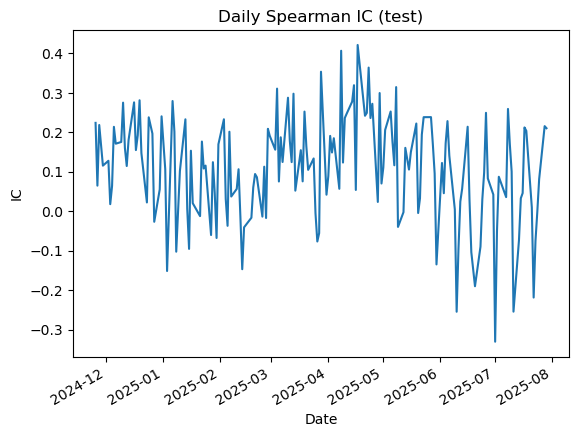

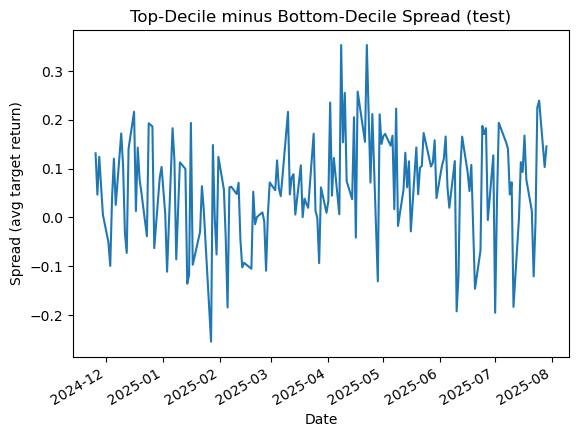

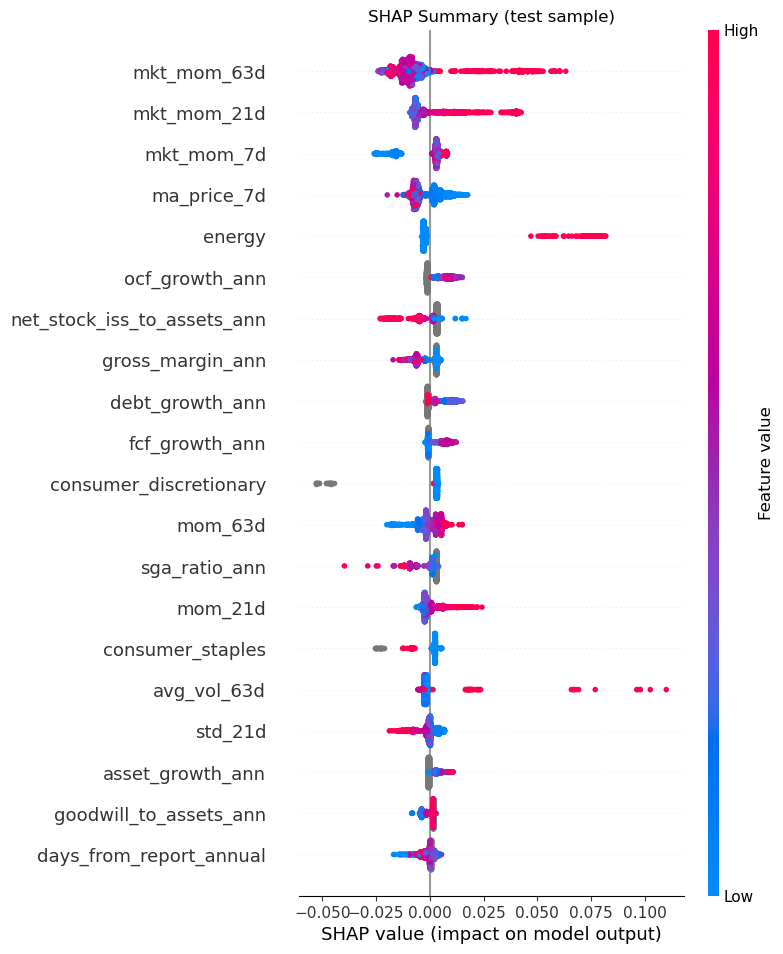

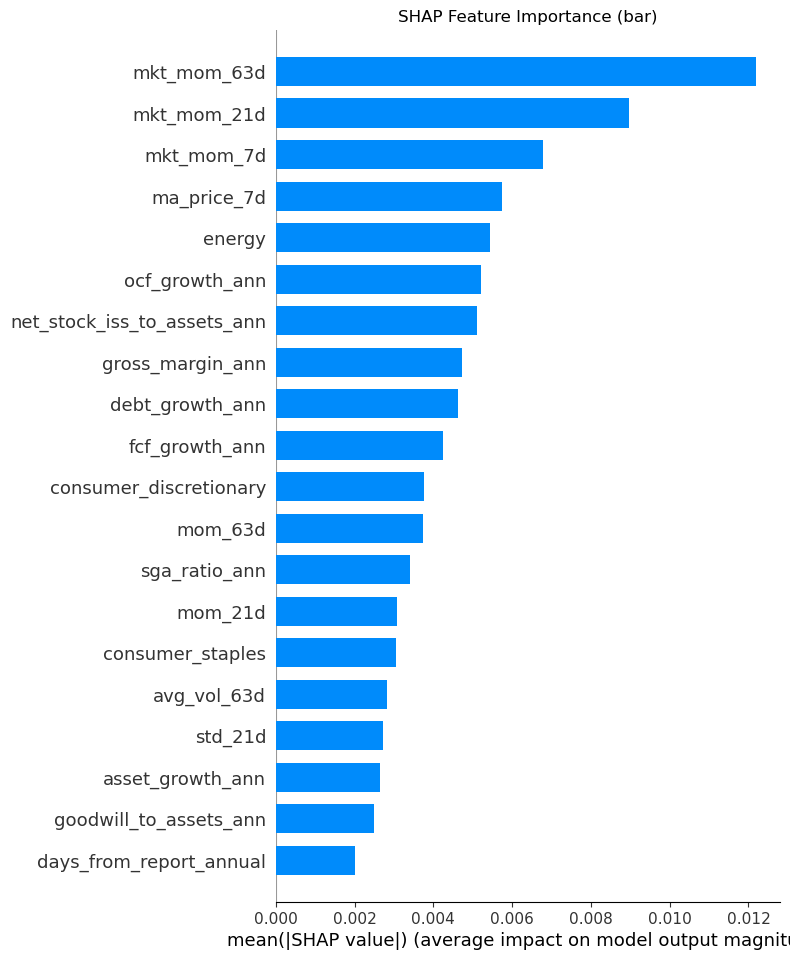

{'train': {'rmse': 0.15189317382007692,
  'mae': 0.1157815891289694,
  'r2': 0.19583119949519434},
 'valid': {'rmse': 0.18004149130736205,
  'mae': 0.13656170741950435,
  'r2': -0.038729761868206314,
  'mean_spearman_ic': 0.024459852462628797,
  'avg_top_minus_bottom_decile': 0.020601467974332172,
  'avg_top_minus_mean_topn': 0.003533359086406527},
 'test': {'rmse': 0.19979034780343313,
  'mae': 0.1451178355190422,
  'r2': -0.001686256475015968,
  'mean_spearman_ic': 0.10801865491015732,
  'avg_top_minus_bottom_decile': 0.06177229595694247,
  'avg_top_minus_mean_topn': 0.02304714473039182},
 'split': {'train_end': '2024-03-14 04:00:00+00:00',
  'valid_end': '2024-11-22 05:00:00+00:00'},
 'xgb_params': {'n_estimators': 1500,
  'learning_rate': 0.01,
  'max_depth': 2,
  'min_child_weight': 20,
  'subsample': 0.7,
  'colsample_bytree': 0.7,
  'reg_alpha': 0.5,
  'reg_lambda': 5.0,
  'objective': 'reg:squarederror',
  'random_state': 42,
  'n_jobs': -1}}

In [30]:
trainer = XGBPanelTrainer(feature_cols=feature_cols, target_col="out_ret_90d")

model, metrics = trainer.fit(
    merged.loc[merged[label].notna()],
    xgb_params={"max_depth": 2, "learning_rate": 0.01},
    plot=True,
    plot_shap=True,
    save_plots=True,
    save_dir="artifacts/run_001",
)

# Posthoc:
daily_ic = trainer.daily_ic_
daily_spread = trainer.daily_spread_
metrics

In [50]:
joblib.dump(model, "model/xgboost_model.joblib")
loaded_model = joblib.load("model/xgboost_model.joblib")

## Post-Hoc Evaluation

In [31]:
daily_ic = trainer.daily_ic_.reset_index().rename(columns={0: 'spearman_ic'})

<Axes: title={'center': 'Daily Spearman IC in Jul-Aug 2025'}, xlabel='date'>

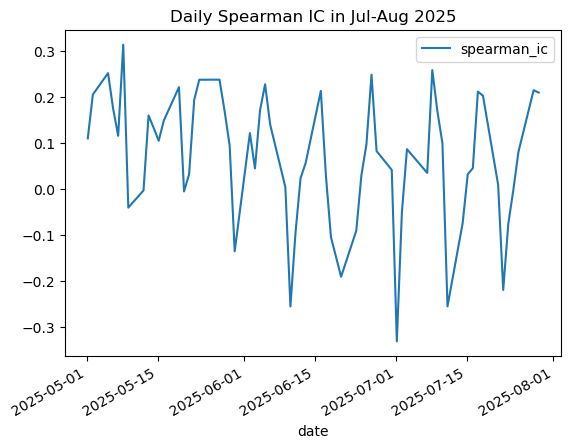

In [32]:
daily_ic.loc[(daily_ic.date > '2025-05-01') & (daily_ic.date < '2025-08-31')].plot(x='date', y='spearman_ic', title='Daily Spearman IC in Jul-Aug 2025')

In [33]:
test_eval = trainer.test_eval_
test_eval = test_eval.merge(metadata[['symbol', 'gics_sector']].set_index('symbol'), left_on='ticker', right_index=True, how='left')
test_eval['weekday'] = test_eval.date.dt.weekday
test_eval['month'] = test_eval.date.dt.month
test_eval['ismonthend'] = test_eval.date.dt.is_month_end.astype(int)
test_eval.head()

,ticker,date,target,pred,gics_sector,weekday,month,ismonthend
68987,ABBV,2024-11-25 05:00:00+00:00,0.079106,0.005494,Health Care,0,11,0
68988,ADBE,2024-11-25 05:00:00+00:00,-0.325082,0.020121,Information Technology,0,11,0
68989,AES,2024-11-25 05:00:00+00:00,-0.142082,0.046748,Utilities,0,11,0
68990,AMCR,2024-11-25 05:00:00+00:00,-0.111131,0.028256,Materials,0,11,0
68991,AMGN,2024-11-25 05:00:00+00:00,0.000151,0.015856,Health Care,0,11,0


In [34]:
test_eval['ismonthend'].value_counts()

ismonthend
0    11414
1      428
Name: count, dtype: int64

In [35]:
groupby_col = 'gics_sector'
groupby_ic, _ = spearman_ic_by_date(
    test_eval, pred_col="pred", y_col="target", date_col="date", groupby_col= groupby_col
)
groupby_spread, _ = top_bottom_spread_by_date(
    test_eval, pred_col="pred", y_col="target", date_col="date", groupby_col= groupby_col
)
groupby_topn, _ = top_bottom_spread_by_date(
    test_eval, pred_col="pred", y_col="target", date_col="date", top_N=20, benchmark="top_minus_mean", groupby_col= groupby_col
)

groupby_eval = ( 
    groupby_ic.reset_index().rename(columns={0: 'spearman_ic'})
    .merge(
        groupby_spread.reset_index().rename(columns={0: 'top_bottom_spread'}), 
        on=groupby_col, 
        how='left'
    )
    .merge(
        groupby_topn.reset_index().rename(columns={0: 'top20_minus_mean_spread'}),
        on=groupby_col,
        how='left'
    )
    )


groupby_eval

,gics_sector,spearman_ic,top_bottom_spread,top20_minus_mean_spread
0,Communication Services,0.121130,-0.093430,0.034912
1,Consumer Discretionary,0.137122,0.129658,0.188303
2,Consumer Staples,0.131289,0.059589,0.005778
3,Energy,-0.084389,-0.001753,0.001651
4,Financials,0.066269,0.048070,0.120155
5,Health Care,-0.028721,0.024905,0.087247
6,Industrials,0.005017,-0.005259,0.002500
7,Information Technology,0.055092,0.048892,0.047881
8,Materials,0.024090,0.022971,0.024177
9,Real Estate,0.121032,0.026566,0.010481


## Pred

In [48]:
loaded_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=20, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [49]:
out_df =merged.loc[merged.date==merged.date.drop_duplicates().sort_values().reset_index(drop=True)[1190]][['date', 'ticker']]
out_df['pred'] =loaded_model.predict(merged.loc[merged.date==merged.date.drop_duplicates().sort_values().reset_index(drop=True)[1190]][feature_cols])

In [39]:
out_df.sort_values('pred', ascending=False).head(10)

,date,ticker,pred
82569,2025-09-03 04:00:00+00:00,NVDA,0.108916
82546,2025-09-03 04:00:00+00:00,EQT,0.098212
82541,2025-09-03 04:00:00+00:00,CTRA,0.096183
82529,2025-09-03 04:00:00+00:00,APA,0.074807
82560,2025-09-03 04:00:00+00:00,KLAC,0.061015
82539,2025-09-03 04:00:00+00:00,CPRT,0.054637
82550,2025-09-03 04:00:00+00:00,FTNT,0.054352
82525,2025-09-03 04:00:00+00:00,AAPL,0.053775
82534,2025-09-03 04:00:00+00:00,CARR,0.053229
82561,2025-09-03 04:00:00+00:00,LKQ,0.049279


In [38]:
out_df.sort_values('pred', ascending=False).tail(10)

,date,ticker,pred
82536,2025-09-03 04:00:00+00:00,CHRW,0.024394
82576,2025-09-03 04:00:00+00:00,REGN,0.022670
82540,2025-09-03 04:00:00+00:00,CRL,0.022339
82542,2025-09-03 04:00:00+00:00,DECK,0.018226
82557,2025-09-03 04:00:00+00:00,IQV,0.016986
82573,2025-09-03 04:00:00+00:00,PEP,0.014539
82589,2025-09-03 04:00:00+00:00,WMT,0.014510
82538,2025-09-03 04:00:00+00:00,COIN,0.013995
82583,2025-09-03 04:00:00+00:00,TKO,0.011694
82585,2025-09-03 04:00:00+00:00,TTWO,-0.022201
